# This notebook is only for EDA

In [47]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
TARGET_SIZE = (224, 224)

DATASET_PATH = Path('/content/drive/MyDrive/Code/AI/ML/Original')

def get_class_distribution(base_path):
    """
    Scans the base directory, treating each subfolder as a class,
    and counts the number of image files within each.
    """
    class_counts = {}
    total_samples = 0

    if not base_path.exists():
        print(f"Error: The path {base_path} could not be found.")
        return None, 0

    for class_dir in base_path.iterdir():
        if class_dir.is_dir():
            class_name = class_dir.name

            # Count valid image files in the subfolder
            count = sum(1 for f in class_dir.glob('*.*') if f.suffix.lower() in ['.jpg', '.png', '.jpeg'])

            class_counts[class_name] = count
            total_samples += count

    # Convert pandas DataFrame
    df_counts = pd.DataFrame(list(class_counts.items()), columns=['Rice Type', 'Sample Count'])

    # Sort the dataframe from highest to lowest
    df_counts = df_counts.sort_values(by='Sample Count', ascending=False).reset_index(drop=True)

    return df_counts, total_samples

# ==========================================
# Execution
# ==========================================
distribution_df, total_images = get_class_distribution(DATASET_PATH)

if distribution_df is not None:
    print(f"Total Samples (All Types Combined): {total_images}")
    print(f"Total Unique Rice Types: {len(distribution_df)}")
    print("\n--- Distribution per Rice Type ---")
    display(distribution_df)

Total Samples (All Types Combined): 4731
Total Unique Rice Types: 20

--- Distribution per Rice Type ---


,Rice Type,Sample Count
0,12_Gutisharna,256
1,9_Bashful,252
2,18_Amon,251
3,15_Katari_Polao,242
4,13_Red_Cargo,240
5,19_Shorna5,238
6,17_Chinigura_Polao,237
7,4_Shampakatari,234
8,8_Paijam,234
9,7_BR29,233


1 Dataset Indexing

In [39]:
def index_dataset(base_path):
    """Indexes all images and their corresponding class labels from the directory structure."""
    dataset = []
    if not base_path.exists():
        return pd.DataFrame()

    for class_dir in base_path.iterdir():
        if class_dir.is_dir():
            label = class_dir.name
            for img_path in class_dir.glob('*.*'):
                if img_path.suffix.lower() in ['.jpg', '.png', '.jpeg']:
                    dataset.append({'image_path': str(img_path), 'label': label})

    return pd.DataFrame(dataset)

# Execute Indexing
dataset_index = index_dataset(DATASET_PATH)

if not dataset_index.empty:
    print(f"Indexing Complete: Found {len(dataset_index)} images across {dataset_index['label'].nunique()} classes.")
    print("\n--- Dataset Index Information ---")
    dataset_index.info()
else:
    print("System Error: The specified DATASET_PATH could not be resolved.")

Indexing Complete: Found 4731 images across 20 classes.

--- Dataset Index Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4731 entries, 0 to 4730
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  4731 non-null   object
 1   label       4731 non-null   object
dtypes: object(2)
memory usage: 74.1+ KB


Sequential Image Processing & Extraction

In [40]:
def process_and_extract_features(row):
    """Reads the image, standardizes dimensions, and extracts features."""
    path = row['image_path']
    img = cv2.imread(path)
    if img is None:
        return None

    img_resized = cv2.resize(img, TARGET_SIZE)
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    # 1. Color Channel Statistics
    r_mean, g_mean, b_mean = np.mean(img_rgb, axis=(0, 1))

    # 2. Sharpness Evaluation
    gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

    # 3. Morphological Feature Extraction
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    area, aspect_ratio = 0.0, 0.0
    if contours:
        main_contour = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(main_contour)
        x, y, w, h = cv2.boundingRect(main_contour)
        aspect_ratio = float(w) / h if h != 0 else 0.0

    return {
        'image_path': path, 'label': row['label'],
        'r_mean': r_mean, 'g_mean': g_mean, 'b_mean': b_mean,
        'blur_score': blur_score, 'grain_area': area, 'aspect_ratio': aspect_ratio
    }

# Execute Extraction
max_samples = 2000
sampled_df = dataset_index.sample(n=min(max_samples, len(dataset_index)), random_state=42)
print(f"Initiating feature extraction for {len(sampled_df)} standardized images...")

results = [process_and_extract_features(row) for _, row in sampled_df.iterrows()]
stats_df = pd.DataFrame([res for res in results if res is not None])

print("\n--- Extracted Features Information ---")
stats_df.info()

Initiating feature extraction for 2000 standardized images...

--- Extracted Features Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   image_path    2000 non-null   object 
 1   label         2000 non-null   object 
 2   r_mean        2000 non-null   float64
 3   g_mean        2000 non-null   float64
 4   b_mean        2000 non-null   float64
 5   blur_score    2000 non-null   float64
 6   grain_area    2000 non-null   float64
 7   aspect_ratio  2000 non-null   float64
dtypes: float64(6), object(2)
memory usage: 125.1+ KB


Visual Analytics

/tmp/ipykernel_2553/1991052236.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset_index, x='label', order=dataset_index['label'].value_counts().index, palette='viridis')


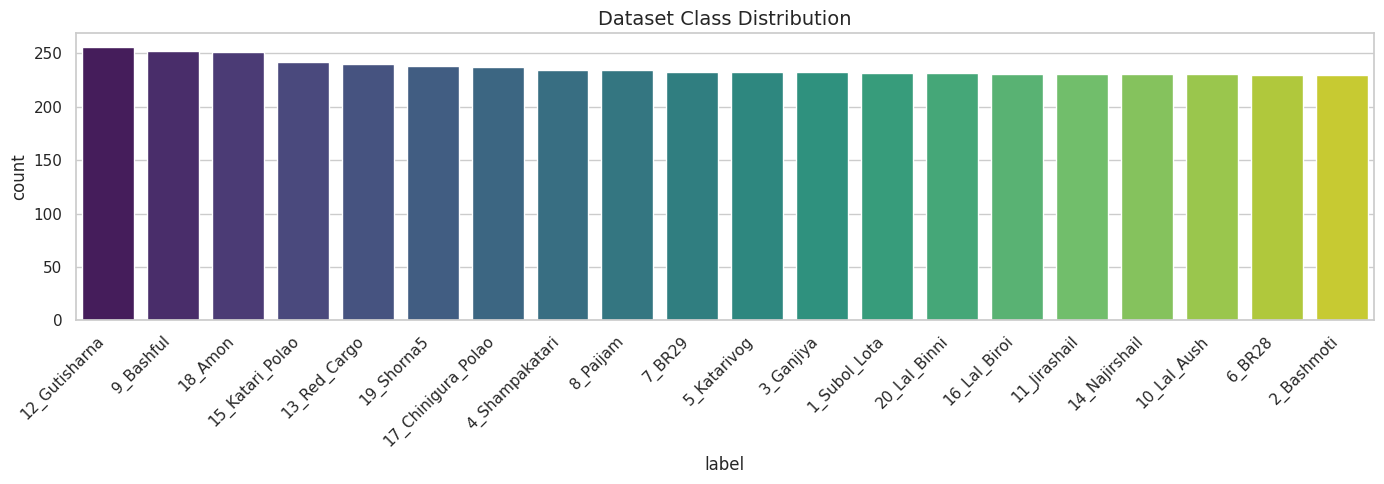

In [41]:
plt.figure(figsize=(14, 5))
sns.countplot(data=dataset_index, x='label', order=dataset_index['label'].value_counts().index, palette='viridis')
plt.title('Dataset Class Distribution', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

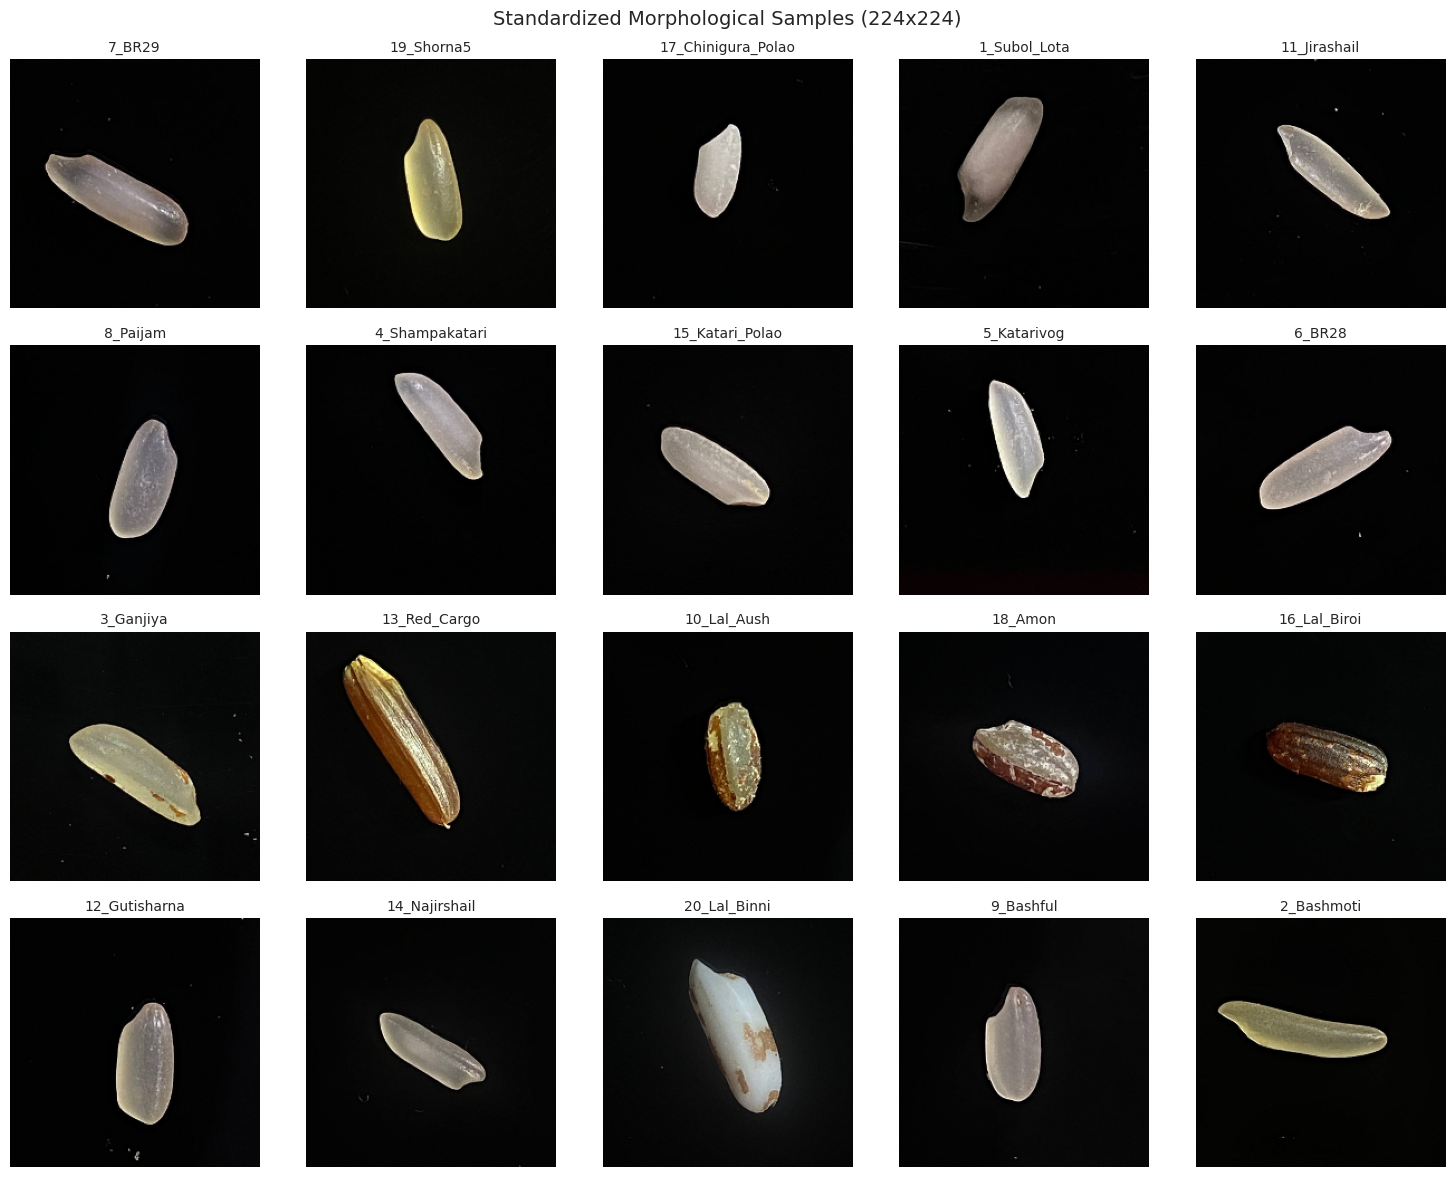

In [42]:
classes = dataset_index['label'].unique()
cols = 5
rows = min(4, (len(classes) + cols - 1) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = axes.flatten()

for i, class_name in enumerate(classes[:20]):
    sample_path = random.choice(dataset_index[dataset_index['label'] == class_name]['image_path'].tolist())
    img = cv2.imread(sample_path)
    if img is not None:
        img_resized = cv2.resize(img, TARGET_SIZE)
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
        axes[i].set_title(class_name, fontsize=10)
    axes[i].axis('off')

for j in range(len(classes[:20]), len(axes)):
    axes[j].axis('off')

plt.suptitle("Standardized Morphological Samples (224x224)", fontsize=14)
plt.tight_layout()
plt.show()

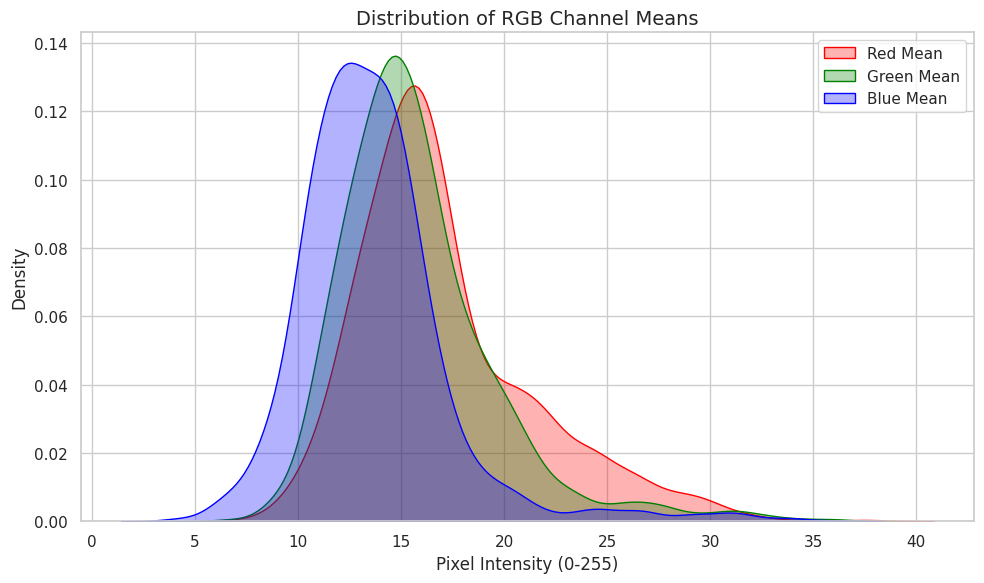

In [43]:
plt.figure(figsize=(10, 6))
sns.kdeplot(stats_df['r_mean'], color='red', label='Red Mean', fill=True, alpha=0.3)
sns.kdeplot(stats_df['g_mean'], color='green', label='Green Mean', fill=True, alpha=0.3)
sns.kdeplot(stats_df['b_mean'], color='blue', label='Blue Mean', fill=True, alpha=0.3)
plt.title('Distribution of RGB Channel Means', fontsize=14)
plt.xlabel('Pixel Intensity (0-255)')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_2553/196184368.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='label', y='grain_area', data=stats_df, palette='Set2')
/tmp/ipykernel_2553/196184368.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_2553/196184368.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='label', y='aspect_ratio', data=stats_df, palette='Set3')
/tmp/ipykernel_2553/196184368.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a 

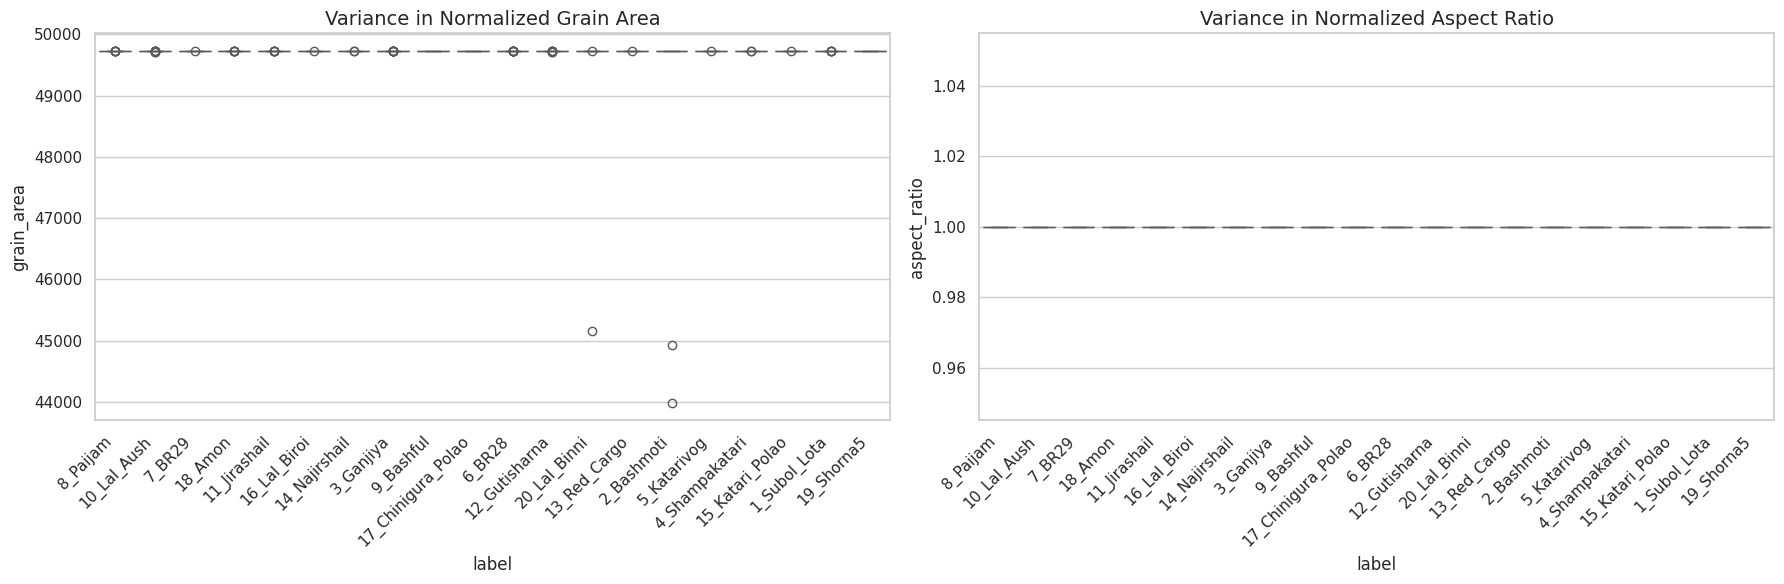

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(ax=axes[0], x='label', y='grain_area', data=stats_df, palette='Set2')
axes[0].set_title('Variance in Normalized Grain Area', fontsize=14)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

sns.boxplot(ax=axes[1], x='label', y='aspect_ratio', data=stats_df, palette='Set3')
axes[1].set_title('Variance in Normalized Aspect Ratio', fontsize=14)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

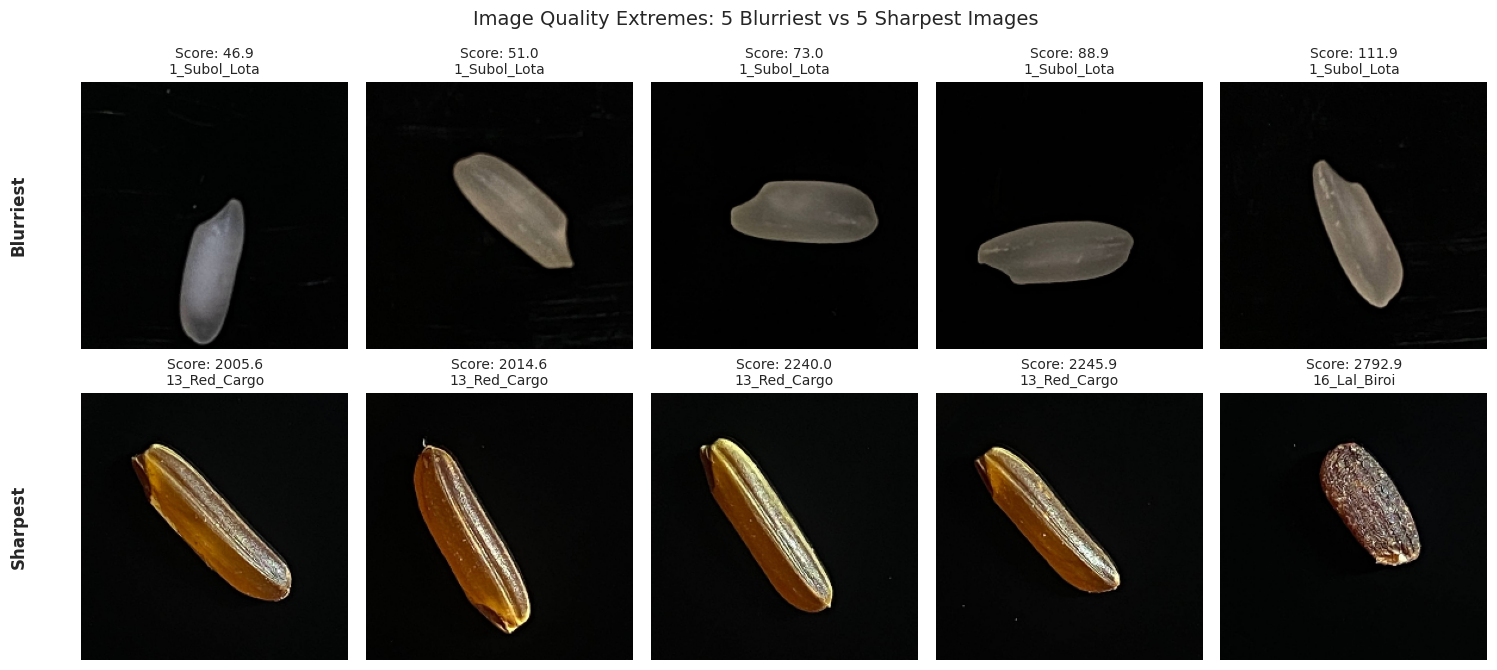

In [45]:
stats_sorted = stats_df.sort_values(by='blur_score')
blurry_samples = stats_sorted.head(5)
sharp_samples = stats_sorted.tail(5)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for i, (_, row) in enumerate(blurry_samples.iterrows()):
    img = cv2.cvtColor(cv2.resize(cv2.imread(row['image_path']), TARGET_SIZE), cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Score: {row['blur_score']:.1f}\n{row['label']}", fontsize=10)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].text(-0.2, 0.5, 'Blurriest', va='center', ha='right', rotation=90, transform=axes[0, i].transAxes, fontsize=12, fontweight='bold')

for i, (_, row) in enumerate(sharp_samples.iterrows()):
    img = cv2.cvtColor(cv2.resize(cv2.imread(row['image_path']), TARGET_SIZE), cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Score: {row['blur_score']:.1f}\n{row['label']}", fontsize=10)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].text(-0.2, 0.5, 'Sharpest', va='center', ha='right', rotation=90, transform=axes[1, i].transAxes, fontsize=12, fontweight='bold')

plt.suptitle("Image Quality Extremes: 5 Blurriest vs 5 Sharpest Images", fontsize=14)
plt.tight_layout()
plt.show()

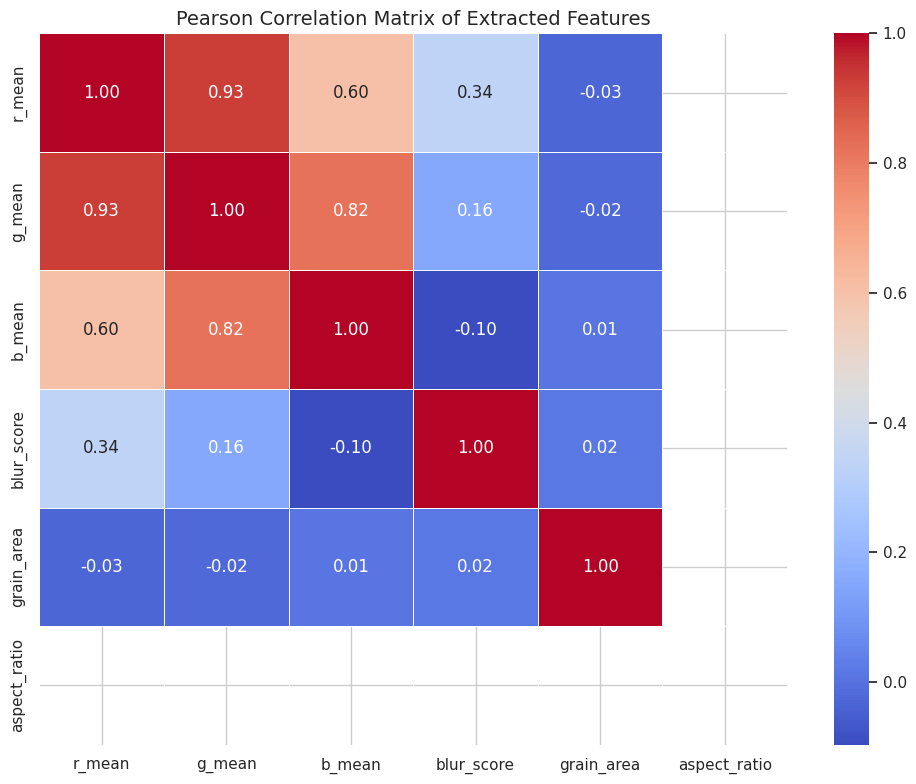

In [46]:
numeric_columns = ['r_mean', 'g_mean', 'b_mean', 'blur_score', 'grain_area', 'aspect_ratio']
correlation_data = stats_df[numeric_columns]

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Pearson Correlation Matrix of Extracted Features', fontsize=14)
plt.tight_layout()
plt.show()